In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from datetime import datetime
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [223]:
df = pd.read_excel("Hospital_Data_Export.xlsx")
df.head()

,Id,FirstName,LastName,NationalId,Email,PhoneNumber,PhoneNumber2,DateOfBirth,Gender,Address,...,InsuranceProvider,InsuranceNumber,MedicalHistory,Allergies,CurrentMedications,IsActive,UserId,CreatedAt,UpdatedAt,IsDeleted
0,1,Mohamed,Youssef,9876543210,m.youssef@example.com,1111111111,NaN,1985-05-15 00:00:00.0000000,Male,"Cairo, Egypt",...,HealthCo,INS-001,No chronic disease,NaN,NaN,True,39d7c0cc-7429-4851-a4fb-5bc10fc07cf7,2025-11-05 17:20:23.1032333,NaN,False
1,2,Salma,Khaled,8765432109,salma.khaled@example.com,1122222222,NaN,1992-03-10 00:00:00.0000000,Female,"Giza, Egypt",...,MedicAid,INS-002,NaN,Penicillin,NaN,True,70cb71a0-ab4a-42e2-8faa-9aef54f2bd94,2025-11-05 17:20:23.1033472,NaN,False
2,3,Hassan,Mahmoud,7654321098,hassan.mahmoud@example.com,1133333333,NaN,1978-09-01 00:00:00.0000000,Male,"Alexandria, Egypt",...,MedicAid,INS-003,NaN,NaN,NaN,True,ed978cdf-236a-44a6-8d70-c43b4b609eb0,2025-11-05 17:20:24.1123016,NaN,False
3,4,Nora,Adel,6543210987,nora.adel@example.com,1144444444,NaN,1995-01-22 00:00:00.0000000,Female,"Cairo, Egypt",...,NaN,NaN,NaN,Ibuprofen,NaN,True,31d699e8-5509-4634-9fca-ec52da9bb388,2025-11-05 17:20:24.1123043,NaN,False
4,5,Yasmine,Fouad,5432109876,yasmine.fouad@example.com,1155555555,NaN,2001-07-30 00:00:00.0000000,Female,"Giza, Egypt",...,NaN,NaN,NaN,NaN,NaN,True,33a65834-b67c-49a4-89f2-23b81a61d2f3,2025-11-05 17:20:24.1123047,NaN,False


In [224]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Id                     120 non-null    int64  
 1   FirstName              120 non-null    object 
 2   LastName               120 non-null    object 
 3   NationalId             120 non-null    object 
 4   Email                  120 non-null    object 
 5   PhoneNumber            120 non-null    int64  
 6   PhoneNumber2           0 non-null      float64
 7   DateOfBirth            120 non-null    object 
 8   Gender                 120 non-null    object 
 9   Address                120 non-null    object 
 10  EmergencyContactName   117 non-null    object 
 11  EmergencyContactPhone  117 non-null    float64
 12  InsuranceProvider      77 non-null     object 
 13  InsuranceNumber        77 non-null     object 
 14  MedicalHistory         68 non-null     object 
 15  Allerg

In [225]:
cols_to_drop = ['PhoneNumber2', 'CurrentMedications', 'UpdatedAt', 'UserId']
df.drop(columns=cols_to_drop, inplace=True)

In [226]:
df.columns

Index(['Id', 'FirstName', 'LastName', 'NationalId', 'Email', 'PhoneNumber',
       'DateOfBirth', 'Gender', 'Address', 'EmergencyContactName',
       'EmergencyContactPhone', 'InsuranceProvider', 'InsuranceNumber',
       'MedicalHistory', 'Allergies', 'IsActive', 'CreatedAt', 'IsDeleted'],
      dtype='object')

### Columns with 100% missing values (PhoneNumber2, CurrentMedications, UpdatedAt) were dropped as they do not provide analytical value in the current dataset. However, some of these fields (e.g., CurrentMedications) may be important for future data collection and analysis

In [227]:
df[["Id", "EmergencyContactName", "EmergencyContactPhone"]] 

,Id,EmergencyContactName,EmergencyContactPhone
0,1,A. Youssef,1.200000e+09
1,2,K. Khaled,1.211111e+09
2,3,NaN,NaN
3,4,NaN,NaN
4,5,NaN,NaN
...,...,...,...
115,1067,أخ - عبدالله,1.610000e+09
116,1068,أخت - منى,1.710000e+09
117,1069,أخ - سامي,1.810000e+09
118,1070,أخت - أسماء,1.910000e+09


In [228]:
df.query("EmergencyContactName.isna() or EmergencyContactPhone.isna()")

,Id,FirstName,LastName,NationalId,Email,PhoneNumber,DateOfBirth,Gender,Address,EmergencyContactName,EmergencyContactPhone,InsuranceProvider,InsuranceNumber,MedicalHistory,Allergies,IsActive,CreatedAt,IsDeleted
2,3,Hassan,Mahmoud,7654321098,hassan.mahmoud@example.com,1133333333,1978-09-01 00:00:00.0000000,Male,"Alexandria, Egypt",NaN,NaN,MedicAid,INS-003,NaN,NaN,True,2025-11-05 17:20:24.1123016,False
3,4,Nora,Adel,6543210987,nora.adel@example.com,1144444444,1995-01-22 00:00:00.0000000,Female,"Cairo, Egypt",NaN,NaN,NaN,NaN,NaN,Ibuprofen,True,2025-11-05 17:20:24.1123043,False
4,5,Yasmine,Fouad,5432109876,yasmine.fouad@example.com,1155555555,2001-07-30 00:00:00.0000000,Female,"Giza, Egypt",NaN,NaN,NaN,NaN,NaN,NaN,True,2025-11-05 17:20:24.1123047,False


In [229]:
df['HasEmergencyContact'] = (
    df['EmergencyContactName'].notna() & 
    df['EmergencyContactPhone'].notna()
).astype(int)

In [230]:
df['EmergencyContactName'].fillna('Unknown', inplace=True)
df['EmergencyContactPhone'].fillna(0, inplace=True)

C:\Users\Hp\AppData\Local\Temp\ipykernel_10400\3503339576.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['EmergencyContactName'].fillna('Unknown', inplace=True)
C:\Users\Hp\AppData\Local\Temp\ipykernel_10400\3503339576.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For

In [231]:
df['HasInsurance'] = df['InsuranceProvider'].notna().astype(int)
df['InsuranceProvider'].fillna('No Insurance', inplace=True)
df['InsuranceNumber'].fillna('N/A', inplace=True)

C:\Users\Hp\AppData\Local\Temp\ipykernel_10400\4221568653.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['InsuranceProvider'].fillna('No Insurance', inplace=True)
C:\Users\Hp\AppData\Local\Temp\ipykernel_10400\4221568653.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

F

In [232]:
df.query("HasInsurance == 0").head()

,Id,FirstName,LastName,NationalId,Email,PhoneNumber,DateOfBirth,Gender,Address,EmergencyContactName,EmergencyContactPhone,InsuranceProvider,InsuranceNumber,MedicalHistory,Allergies,IsActive,CreatedAt,IsDeleted,HasEmergencyContact,HasInsurance
3,4,Nora,Adel,6543210987,nora.adel@example.com,1144444444,1995-01-22 00:00:00.0000000,Female,"Cairo, Egypt",Unknown,0.000000e+00,No Insurance,N/A,NaN,Ibuprofen,True,2025-11-05 17:20:24.1123043,False,0,0
4,5,Yasmine,Fouad,5432109876,yasmine.fouad@example.com,1155555555,2001-07-30 00:00:00.0000000,Female,"Giza, Egypt",Unknown,0.000000e+00,No Insurance,N/A,NaN,NaN,True,2025-11-05 17:20:24.1123047,False,0,0
6,7,Sara,Youssef,P0000000007,patient7@example.com,1100000007,1973-11-01 00:00:00.0000000,Female,"Giza, Egypt",EC,1.200000e+09,No Insurance,N/A,Diabetes,NaN,True,2025-11-05 17:20:24.4622007,False,1,0
7,8,Omar,Ali,P0000000008,patient8@example.com,1100000008,1974-05-20 00:00:00.0000000,Male,"Cairo, Egypt",EC,1.200000e+09,No Insurance,N/A,NaN,NaN,True,2025-11-05 17:20:24.4622035,False,1,0
8,9,Mohamed,Hassan,P0000000009,patient9@example.com,1100000009,1974-12-06 00:00:00.0000000,Female,"Giza, Egypt",EC,1.200000e+09,No Insurance,N/A,NaN,NaN,True,2025-11-05 17:20:24.4622061,False,1,0


In [233]:
df['MedicalHistory'].fillna('No History', inplace=True)
df['HasMedicalHistory'] = (df['MedicalHistory'] != 'No History').astype(int)

C:\Users\Hp\AppData\Local\Temp\ipykernel_10400\3177440039.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['MedicalHistory'].fillna('No History', inplace=True)


In [234]:
df['Allergies'].fillna('No Allergies', inplace=True)
df['HasAllergies'] = (df['Allergies'] != 'No Allergies').astype(int)

C:\Users\Hp\AppData\Local\Temp\ipykernel_10400\4093945187.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Allergies'].fillna('No Allergies', inplace=True)


In [235]:
pd.crosstab(df['HasMedicalHistory'], df['HasAllergies'])

HasAllergies,0,1
HasMedicalHistory,,
0,38,14
1,20,48


#### Patients with prior medical conditions are significantly more likely to have allergies (≈70%) compared to individuals without medical history (≈27%), indicating a strong relationship between chronic conditions and allergic responses.

In [236]:
df.isnull().sum()

Id                       0
FirstName                0
LastName                 0
NationalId               0
Email                    0
PhoneNumber              0
DateOfBirth              0
Gender                   0
Address                  0
EmergencyContactName     0
EmergencyContactPhone    0
InsuranceProvider        0
InsuranceNumber          0
MedicalHistory           0
Allergies                0
IsActive                 0
CreatedAt                0
IsDeleted                0
HasEmergencyContact      0
HasInsurance             0
HasMedicalHistory        0
HasAllergies             0
dtype: int64

In [237]:
df['DateOfBirth'] = pd.to_datetime(df['DateOfBirth'])
today = pd.to_datetime('today')
df['Age'] = (today - df['DateOfBirth']).dt.days // 365

In [238]:
df["Gender"].value_counts()

Gender
Male      60
Female    60
Name: count, dtype: int64

In [239]:
df.describe()

,Id,PhoneNumber,DateOfBirth,EmergencyContactPhone,HasEmergencyContact,HasInsurance,HasMedicalHistory,HasAllergies,Age
count,120.000000,1.200000e+02,120,1.200000e+02,120.00000,120.000000,120.000000,120.000000,120.000000
mean,615.250000,1.305556e+09,1978-08-06 07:24:00,1.321759e+09,0.97500,0.641667,0.566667,0.516667,47.258333
min,1.000000,1.000000e+09,1963-12-19 00:00:00,0.000000e+00,0.00000,0.000000,0.000000,0.000000,24.000000
25%,30.750000,1.100000e+09,1972-02-10 00:00:00,1.200000e+09,1.00000,0.000000,0.000000,0.000000,42.750000
50%,1011.500000,1.116667e+09,1977-10-18 12:00:00,1.200000e+09,1.00000,1.000000,1.000000,1.000000,48.000000
75%,1041.250000,1.500000e+09,1983-04-13 00:00:00,1.510000e+09,1.00000,1.000000,1.000000,1.000000,54.000000
max,1071.000000,1.900000e+09,2001-07-30 00:00:00,1.910000e+09,1.00000,1.000000,1.000000,1.000000,62.000000
std,500.846783,2.793513e+08,NaN,3.311311e+08,0.15678,0.481521,0.497613,0.501817,8.900473


##### Count of Patient : 120
##### Average of Age : 47
##### Count of male is 60 and female 60

In [240]:
df1 = pd.read_excel("Hospital_Data_Export.xlsx", sheet_name="Appointments")
df1.head()

,Id,AppointmentDate,AppointmentTime,Status,Reason,Notes,Diagnosis,Treatment,ConsultationFee,IsFollowUp,PatientId,DoctorId,RoomId,CreatedAt,UpdatedAt,IsDeleted
0,1,2025-11-06 00:00:00.0000000,10:00:00.0000000,Scheduled,Chest pain,Patient reports intermittent pain,NaN,NaN,250,False,1,1,1,2025-11-05 17:20:23.2950633,NaN,False
1,2,2025-11-04 00:00:00.0000000,11:30:00.0000000,Completed,Headache,NaN,Migraine,Pain management,300,False,2,2,2,2025-11-05 17:20:23.2967572,NaN,False
2,3,2025-11-07 00:00:00.0000000,09:30:00.0000000,Scheduled,Follow up,NaN,NaN,NaN,250,False,3,1,1,2025-11-05 17:20:24.1523625,NaN,False
3,4,2025-11-08 00:00:00.0000000,15:00:00.0000000,Scheduled,Knee pain,NaN,NaN,NaN,220,False,4,3,3,2025-11-05 17:20:24.1523650,NaN,False
4,5,2025-11-05 00:00:00.0000000,12:00:00.0000000,Confirmed,Fever,NaN,NaN,NaN,90,False,5,1,4,2025-11-05 17:20:24.1523658,NaN,False


In [241]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151 entries, 0 to 150
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Id               151 non-null    int64  
 1   AppointmentDate  151 non-null    object 
 2   AppointmentTime  151 non-null    object 
 3   Status           151 non-null    object 
 4   Reason           151 non-null    object 
 5   Notes            1 non-null      object 
 6   Diagnosis        1 non-null      object 
 7   Treatment        1 non-null      object 
 8   ConsultationFee  151 non-null    int64  
 9   IsFollowUp       151 non-null    bool   
 10  PatientId        151 non-null    int64  
 11  DoctorId         151 non-null    int64  
 12  RoomId           151 non-null    int64  
 13  CreatedAt        151 non-null    object 
 14  UpdatedAt        0 non-null      float64
 15  IsDeleted        151 non-null    bool   
dtypes: bool(2), float64(1), int64(5), object(8)
memory usage: 16.9

In [242]:
cols_to_drop = ['UpdatedAt', 'Notes', 'Diagnosis', 'Treatment']
df1.drop(columns=cols_to_drop, inplace=True)

In [243]:
df1["Status"].value_counts()

Status
Scheduled    104
Completed     19
Cancelled     15
Confirmed     13
Name: count, dtype: int64

##### The majority of appointments are still in the scheduled stage, while completed appointments represent a small fraction of the dataset, indicating either early-stage data or potential inefficiencies in appointment completion.

In [244]:
df2 = pd.read_excel("Hospital_Data_Export.xlsx", sheet_name="Bills")
df2.head()

,Id,BillNumber,BillDate,DueDate,Status,SubTotal,TaxAmount,DiscountAmount,TotalAmount,PaidAmount,...,PaymentMethod,PaymentDate,Notes,InsuranceProvider,InsuranceNumber,InsuranceCoverage,PatientId,CreatedAt,UpdatedAt,IsDeleted
0,1,BILL-20251105-0001,2025-11-05 00:00:00.0000000,2025-11-12 00:00:00.0000000,Paid,370,51.8,0,421.8,421.8,...,cash,2026-01-06 14:24:21.6033158,Consultation and medicine,HealthCo,INS-001,80.0,1,2025-11-05 17:20:23.8412464,2026-01-06 14:24:21.6033183,False
1,2,BILL-20251105-0003,2025-11-05 00:00:00.0000000,2025-11-12 00:00:00.0000000,Paid,300,42.0,0,342.0,342.0,...,NaN,NaN,NaN,HealthCo,INS-1000,80.0,20,2025-11-05 17:20:25.4493557,NaN,False
2,3,BILL-20251105-0004,2025-11-04 00:00:00.0000000,2025-11-11 00:00:00.0000000,Pending,225,31.5,0,256.5,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,7,2025-11-05 17:20:25.4497696,NaN,False
3,4,BILL-20251105-0005,2025-11-03 00:00:00.0000000,2025-11-10 00:00:00.0000000,Pending,200,28.0,0,228.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,6,2025-11-05 17:20:25.4497910,NaN,False
4,5,BILL-20251105-0006,2025-11-02 00:00:00.0000000,2025-11-09 00:00:00.0000000,Pending,200,28.0,0,228.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,16,2025-11-05 17:20:25.4498016,NaN,False


In [245]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Id                 100 non-null    int64  
 1   BillNumber         100 non-null    object 
 2   BillDate           100 non-null    object 
 3   DueDate            100 non-null    object 
 4   Status             100 non-null    object 
 5   SubTotal           100 non-null    int64  
 6   TaxAmount          100 non-null    float64
 7   DiscountAmount     100 non-null    int64  
 8   TotalAmount        100 non-null    float64
 9   PaidAmount         100 non-null    float64
 10  RemainingAmount    100 non-null    float64
 11  PaymentMethod      3 non-null      object 
 12  PaymentDate        3 non-null      object 
 13  Notes              1 non-null      object 
 14  InsuranceProvider  23 non-null     object 
 15  InsuranceNumber    23 non-null     object 
 16  InsuranceCoverage  23 non-n

In [246]:
cols_to_drop = ['PaymentMethod', 'PaymentDate', 'Notes', 'UpdatedAt', 'InsuranceNumber', 'InsuranceCoverage']
df2.drop(columns=cols_to_drop, inplace=True)

In [247]:
df2['InsuranceProvider'].fillna('No Insurance', inplace=True)

C:\Users\Hp\AppData\Local\Temp\ipykernel_10400\1154685106.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df2['InsuranceProvider'].fillna('No Insurance', inplace=True)


In [248]:
df2.isnull().sum()

Id                   0
BillNumber           0
BillDate             0
DueDate              0
Status               0
SubTotal             0
TaxAmount            0
DiscountAmount       0
TotalAmount          0
PaidAmount           0
RemainingAmount      0
InsuranceProvider    0
PatientId            0
CreatedAt            0
IsDeleted            0
dtype: int64

In [249]:
total_billed = df2['TotalAmount'].sum()
total_billed

np.float64(27377.1)

In [250]:
total_paid = df2['PaidAmount'].sum()
total_paid

np.float64(6378.3)

In [251]:
total_remaining = df2['RemainingAmount'].sum()
total_remaining

np.float64(20998.8)

In [252]:
collection_rate = (total_paid / total_billed) * 100
collection_rate

np.float64(23.29793878825734)

In [253]:
overdue_rate = (total_remaining / total_billed) * 100
overdue_rate

np.float64(76.70206121174267)

##### The healthcare system shows a significant gap between billed and collected amounts, with a collection rate of only 23.3% and an overdue ratio of 76.7%, indicating potential cash flow and payment collection inefficiencies.

In [254]:
df3 = pd.read_excel("Hospital_Data_Export.xlsx", sheet_name="Doctors")
df3.head()

,Id,FirstName,LastName,NationalId,Email,PhoneNumber,PhoneNumber2,DateOfBirth,Gender,Address,...,ConsultationFee,WorkingHoursStart,WorkingHoursEnd,IsAvailable,IsActive,DepartmentId,UserId,CreatedAt,UpdatedAt,IsDeleted
0,1,Ahmed,Hassan,1111111111,ahmed.hassan@hospital.com,1000000001,NaN,1980-03-20 00:00:00.0000000,Male,Building A,...,250,09:00:00.0000000,17:00:00.0000000,True,True,1,3ee42191-13e5-4880-a4d7-50e11d5d86ce,2025-11-05 17:20:22.9369443,NaN,False
1,2,Sarah,Mohamed,2222222222,sarah.mohamed@hospital.com,1000000002,NaN,1982-06-12 00:00:00.0000000,Female,Building A,...,300,10:00:00.0000000,18:00:00.0000000,True,True,2,78ee8153-0e36-4d5a-b488-7ce9780a4917,2025-11-05 17:20:22.9369906,NaN,False
2,3,Omar,Ali,3333333333,omar.ali@hospital.com,1000000003,NaN,1985-11-05 00:00:00.0000000,Male,Building B,...,220,08:30:00.0000000,16:30:00.0000000,True,True,3,d7695edf-97b9-4855-99be-c9ba650278f3,2025-11-05 17:20:22.9369913,NaN,False
3,4,Khaled,El-Sayed,D1000000002,khaled.el-sayed.12@hospital.com,1010000002,NaN,1975-02-22 00:00:00.0000000,Male,"Floor 2, Building A",...,170,09:00:00.0000000,17:00:00.0000000,True,True,1,f1894996-16a6-4919-92af-c177393ce609,2025-11-05 17:20:24.2853893,NaN,False
4,5,Fatima,Mostafa,D1000000003,fatima.mostafa.13@hospital.com,1010000003,NaN,1975-02-23 00:00:00.0000000,Female,"Floor 2, Building A",...,180,09:00:00.0000000,17:00:00.0000000,True,True,1,f71802c4-7a55-4a75-a7ad-f3fe28fc37a9,2025-11-05 17:20:24.2854030,NaN,False


In [255]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95 entries, 0 to 94
Data columns (total 27 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Id                 95 non-null     int64  
 1   FirstName          95 non-null     object 
 2   LastName           95 non-null     object 
 3   NationalId         95 non-null     object 
 4   Email              95 non-null     object 
 5   PhoneNumber        95 non-null     int64  
 6   PhoneNumber2       0 non-null      float64
 7   DateOfBirth        95 non-null     object 
 8   Gender             95 non-null     object 
 9   Address            95 non-null     object 
 10  LicenseNumber      95 non-null     object 
 11  Specialization     95 non-null     object 
 12  SubSpecialization  2 non-null      object 
 13  YearsOfExperience  95 non-null     int64  
 14  Education          95 non-null     object 
 15  Certifications     94 non-null     object 
 16  Languages          95 non-nu

In [256]:
df3.isnull().sum()

Id                    0
FirstName             0
LastName              0
NationalId            0
Email                 0
PhoneNumber           0
PhoneNumber2         95
DateOfBirth           0
Gender                0
Address               0
LicenseNumber         0
Specialization        0
SubSpecialization    93
YearsOfExperience     0
Education             0
Certifications        1
Languages             0
ConsultationFee       0
WorkingHoursStart     0
WorkingHoursEnd       0
IsAvailable           0
IsActive              0
DepartmentId          0
UserId                0
CreatedAt             0
UpdatedAt            92
IsDeleted             0
dtype: int64

In [257]:
df3['Certifications'].fillna('Unknown', inplace=True)

C:\Users\Hp\AppData\Local\Temp\ipykernel_10400\127872812.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df3['Certifications'].fillna('Unknown', inplace=True)


In [258]:
df3.drop(columns=['PhoneNumber2', 'UpdatedAt', 'SubSpecialization'], inplace=True)

In [259]:
any(df3.isnull().sum())

False

In [260]:
df_merged = df1.merge(
    df2,
    on='PatientId',
    how='inner'
)

In [261]:
doctor_revenue = df_merged.groupby('DoctorId')['TotalAmount'].sum().sort_values(ascending=False)
doctor_revenue.reset_index()

,DoctorId,TotalAmount
0,1,9775.5
1,6,8379.0
2,16,7695.0
3,11,7695.0
4,2,6241.5
5,20,4104.0
6,21,3762.0
7,7,3078.0
8,3,3078.0
9,4,2821.5


In [262]:
df4 =pd.read_excel("Hospital_Data_Export.xlsx", sheet_name="Medicines")
df4.head()

,Id,Name,GenericName,DosageForm,Strength,Manufacturer,Description,Indications,Contraindications,SideEffects,...,StockQuantity,MinimumStockLevel,Unit,ExpiryDate,BatchNumber,RequiresPrescription,IsActive,CreatedAt,UpdatedAt,IsDeleted
0,1,Paracetamol,Acetaminophen,Tablet,500mg,PharmaCorp,Pain reliever and fever reducer,"Headache, fever, muscle pain","Liver disease, alcohol use","Nausea, rash",...,1000,100,tablet,2027-09-15 10:56:42.1932409,PC2024001,False,True,2025-09-15 10:56:42.1932419,2025-11-10 21:00:01.2571492,True
1,2,Amoxicillin,Amoxicillin,Capsule,250mg,MediCorp,Antibiotic for bacterial infections,"Respiratory infections, skin infections",Penicillin allergy,"Diarrhea, nausea, rash",...,500,50,capsule,2027-09-15 10:56:42.1932425,MC2024001,True,True,2025-09-15 10:56:42.1932427,NaN,False
2,1001,Ibuprofen,Ibuprofen,Tablet,400mg,HealthPharma,Anti-inflammatory and pain reliever,"Inflammation, pain, fever","Stomach ulcers, heart disease","Stomach upset, dizziness",...,60,80,tablet,2027-11-05 22:59:23.4856615,HP2024001,False,True,2025-11-05 22:59:23.4856617,NaN,False
3,1002,Metformin,Metformin Hydrochloride,Tablet,850mg,GlucoPharm,Antidiabetic,Type 2 Diabetes,NaN,NaN,...,45,100,tablet,2026-11-05 22:59:23.4856620,GF2024002,True,True,2025-11-05 22:59:23.4856622,NaN,False
4,1003,Lisinopril,Lisinopril,Tablet,10mg,CardioMed,ACE inhibitor,Hypertension,NaN,NaN,...,30,80,tablet,2026-11-05 22:59:23.4856625,CM2024007,True,True,2025-11-05 22:59:23.4856627,NaN,False


In [263]:
df4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Id                    38 non-null     int64  
 1   Name                  38 non-null     object 
 2   GenericName           38 non-null     object 
 3   DosageForm            38 non-null     object 
 4   Strength              38 non-null     object 
 5   Manufacturer          38 non-null     object 
 6   Description           38 non-null     object 
 7   Indications           38 non-null     object 
 8   Contraindications     27 non-null     object 
 9   SideEffects           27 non-null     object 
 10  DosageInstructions    27 non-null     object 
 11  Price                 38 non-null     float64
 12  StockQuantity         38 non-null     int64  
 13  MinimumStockLevel     38 non-null     int64  
 14  Unit                  38 non-null     object 
 15  ExpiryDate            38 

In [264]:
df4.isnull().sum()

Id                       0
Name                     0
GenericName              0
DosageForm               0
Strength                 0
Manufacturer             0
Description              0
Indications              0
Contraindications       11
SideEffects             11
DosageInstructions      11
Price                    0
StockQuantity            0
MinimumStockLevel        0
Unit                     0
ExpiryDate               0
BatchNumber              0
RequiresPrescription     0
IsActive                 0
CreatedAt                0
UpdatedAt               37
IsDeleted                0
dtype: int64

In [265]:
cols = ['Contraindications', 'SideEffects', 'DosageInstructions']

df4[cols] = df4[cols].fillna('Unknown')

In [266]:
df4.isnull().sum()

Id                       0
Name                     0
GenericName              0
DosageForm               0
Strength                 0
Manufacturer             0
Description              0
Indications              0
Contraindications        0
SideEffects              0
DosageInstructions       0
Price                    0
StockQuantity            0
MinimumStockLevel        0
Unit                     0
ExpiryDate               0
BatchNumber              0
RequiresPrescription     0
IsActive                 0
CreatedAt                0
UpdatedAt               37
IsDeleted                0
dtype: int64

In [267]:
df4.drop("UpdatedAt", axis=1, inplace=True)

In [268]:
any(df4.isnull().sum())

False

##### Due to missing prescription linkage in the dataset, medicine usage analysis was approximated using stock levels, where low stock is assumed to indicate high demand and high stock indicates low utilization.

In [269]:
df4.sort_values('StockQuantity', ascending=False).head(10)

,Id,Name,GenericName,DosageForm,Strength,Manufacturer,Description,Indications,Contraindications,SideEffects,...,Price,StockQuantity,MinimumStockLevel,Unit,ExpiryDate,BatchNumber,RequiresPrescription,IsActive,CreatedAt,IsDeleted
0,1,Paracetamol,Acetaminophen,Tablet,500mg,PharmaCorp,Pain reliever and fever reducer,"Headache, fever, muscle pain","Liver disease, alcohol use","Nausea, rash",...,5.0,1000,100,tablet,2027-09-15 10:56:42.1932409,PC2024001,False,True,2025-09-15 10:56:42.1932419,True
14,1013,Aspirin,Acetylsalicylic Acid,Tablet,100mg,CardioPharm,Antiplatelet and pain reliever,"Heart attack prevention, pain relief","Peptic ulcers, bleeding disorders","Stomach irritation, bleeding",...,3.5,800,200,tablet,2027-11-05 22:59:23.4856995,CP2024022,False,True,2025-11-05 22:59:23.4856997,False
28,1027,Calcium Carbonate,Calcium Carbonate,Tablet,500mg,NutriLife,Calcium supplement,"Calcium deficiency, osteoporosis prevention","Hypercalcemia, kidney stones","Constipation, gas",...,4.0,600,200,tablet,2027-11-05 22:59:23.4857135,NL2024036,False,True,2025-11-05 22:59:23.4857137,False
37,1036,Folic Acid,Folic Acid,Tablet,5mg,NutriLife,B vitamin supplement,"Folate deficiency, pregnancy, anemia",Pernicious anemia,Rare - allergic reactions,...,3.0,550,200,tablet,2027-11-05 22:59:23.4857248,NL2024045,False,True,2025-11-05 22:59:23.4857250,False
12,1011,Vitamin D3,Cholecalciferol,Capsule,1000 IU,NutriLife,Supplement,Deficiency,Unknown,Unknown,...,5.5,500,100,capsule,2027-11-05 22:59:23.4856949,NL2024020,False,True,2025-11-05 22:59:23.4856950,False
1,2,Amoxicillin,Amoxicillin,Capsule,250mg,MediCorp,Antibiotic for bacterial infections,"Respiratory infections, skin infections",Penicillin allergy,"Diarrhea, nausea, rash",...,15.0,500,50,capsule,2027-09-15 10:56:42.1932425,MC2024001,True,True,2025-09-15 10:56:42.1932427,False
33,1032,Diphenhydramine,Diphenhydramine,Tablet,25mg,AllerGo,Antihistamine and sedative,"Allergies, insomnia, motion sickness","Glaucoma, urinary retention","Drowsiness, dry mouth, dizziness",...,4.5,500,150,tablet,2027-11-05 22:59:23.4857193,AG2024041,False,True,2025-11-05 22:59:23.4857195,False
21,1020,Diclofenac,Diclofenac Sodium,Tablet,50mg,PainRelief,NSAID pain reliever,"Pain, inflammation, arthritis","Peptic ulcers, kidney disease, heart disease","Stomach upset, kidney problems",...,9.0,450,150,tablet,2027-11-05 22:59:23.4857065,PR2024029,False,True,2025-11-05 22:59:23.4857067,False
27,1026,Loratadine,Loratadine,Tablet,10mg,AllerGo,Antihistamine,"Allergic rhinitis, urticaria",Hypersensitivity,"Drowsiness (rare), dry mouth",...,7.5,420,150,tablet,2027-11-05 22:59:23.4857130,AG2024035,False,True,2025-11-05 22:59:23.4857132,False
16,1015,Levothyroxine,Levothyroxine Sodium,Tablet,50mcg,ThyroMed,Thyroid hormone replacement,Hypothyroidism,"Hyperthyroidism, heart disease","Palpitations, weight loss",...,8.5,400,150,tablet,2027-11-05 22:59:23.4857007,TM2024024,True,True,2025-11-05 22:59:23.4857008,False


In [270]:
df4[df4['StockQuantity'] < df4['MinimumStockLevel']]

,Id,Name,GenericName,DosageForm,Strength,Manufacturer,Description,Indications,Contraindications,SideEffects,...,Price,StockQuantity,MinimumStockLevel,Unit,ExpiryDate,BatchNumber,RequiresPrescription,IsActive,CreatedAt,IsDeleted
2,1001,Ibuprofen,Ibuprofen,Tablet,400mg,HealthPharma,Anti-inflammatory and pain reliever,"Inflammation, pain, fever","Stomach ulcers, heart disease","Stomach upset, dizziness",...,8.00,60,80,tablet,2027-11-05 22:59:23.4856615,HP2024001,False,True,2025-11-05 22:59:23.4856617,False
3,1002,Metformin,Metformin Hydrochloride,Tablet,850mg,GlucoPharm,Antidiabetic,Type 2 Diabetes,Unknown,Unknown,...,12.50,45,100,tablet,2026-11-05 22:59:23.4856620,GF2024002,True,True,2025-11-05 22:59:23.4856622,False
4,1003,Lisinopril,Lisinopril,Tablet,10mg,CardioMed,ACE inhibitor,Hypertension,Unknown,Unknown,...,9.75,30,80,tablet,2026-11-05 22:59:23.4856625,CM2024007,True,True,2025-11-05 22:59:23.4856627,False
6,1005,Atorvastatin,Atorvastatin,Tablet,20mg,LipoPharm,Statin,High cholesterol,Unknown,Unknown,...,14.20,75,150,tablet,2027-11-05 22:59:23.4856800,LP2024012,True,True,2025-11-05 22:59:23.4856801,False
7,1006,Azithromycin,Azithromycin,Tablet,500mg,MacroMed,Antibiotic,Respiratory infections,Unknown,Unknown,...,22.00,40,80,tablet,2026-11-05 22:59:23.4856839,MM2024015,True,True,2025-11-05 22:59:23.4856840,False
9,1008,Salbutamol Inhaler,Albuterol,Inhaler,100mcg/dose,Respira,Bronchodilator,Asthma,Unknown,Unknown,...,55.00,20,60,device,2026-11-05 22:59:23.4856849,RS2024017,True,True,2025-11-05 22:59:23.4856850,False
10,1009,Insulin Glargine,Insulin Glargine,Injection,100 IU/ml,GlucoCare,Long-acting insulin,Diabetes,Unknown,Unknown,...,120.00,15,50,vial,2027-05-05 22:59:23.4856853,GC2024018,True,True,2025-11-05 22:59:23.4856940,False
11,1010,Losartan,Losartan Potassium,Tablet,50mg,CardioMed,ARB,Hypertension,Unknown,Unknown,...,10.00,70,120,tablet,2027-11-05 22:59:23.4856944,CM2024019,True,True,2025-11-05 22:59:23.4856946,False
13,1012,Warfarin,Warfarin Sodium,Tablet,5mg,Coagulo,Anticoagulant,Thrombosis prevention,Unknown,Unknown,...,18.00,25,80,tablet,2027-11-05 22:59:23.4856989,CG2024021,True,True,2025-11-05 22:59:23.4856991,False


In [271]:
df4.sort_values('Price', ascending=False).head(5)

,Id,Name,GenericName,DosageForm,Strength,Manufacturer,Description,Indications,Contraindications,SideEffects,...,Price,StockQuantity,MinimumStockLevel,Unit,ExpiryDate,BatchNumber,RequiresPrescription,IsActive,CreatedAt,IsDeleted
10,1009,Insulin Glargine,Insulin Glargine,Injection,100 IU/ml,GlucoCare,Long-acting insulin,Diabetes,Unknown,Unknown,...,120.0,15,50,vial,2027-05-05 22:59:23.4856853,GC2024018,True,True,2025-11-05 22:59:23.4856940,False
9,1008,Salbutamol Inhaler,Albuterol,Inhaler,100mcg/dose,Respira,Bronchodilator,Asthma,Unknown,Unknown,...,55.0,20,60,device,2026-11-05 22:59:23.4856849,RS2024017,True,True,2025-11-05 22:59:23.4856850,False
26,1025,Montelukast,Montelukast Sodium,Tablet,10mg,Respira,Leukotriene receptor antagonist,"Asthma, allergic rhinitis",Hypersensitivity,"Headache, nausea, sleep disturbances",...,35.0,150,80,tablet,2027-11-05 22:59:23.4857125,RS2024034,True,True,2025-11-05 22:59:23.4857127,False
35,1034,Ciprofloxacin Eye Drops,Ciprofloxacin,Eye Drops,0.3%,OphthaMed,Antibiotic eye drops,"Bacterial eye infections, conjunctivitis",Hypersensitivity,"Eye irritation, burning sensation",...,32.0,120,50,bottle,2027-05-05 22:59:23.4857238,OM2024043,True,True,2025-11-05 22:59:23.4857240,False
32,1031,Fluconazole,Fluconazole,Capsule,150mg,FungiMed,Antifungal medication,"Fungal infections, candidiasis","Hypersensitivity, pregnancy","Nausea, headache, rash",...,28.0,180,80,capsule,2027-11-05 22:59:23.4857188,FM2024040,True,True,2025-11-05 22:59:23.4857190,False


In [272]:
df_cluster = df.merge(df1, left_on='Id', right_on='PatientId') \
                .merge(df2, on='PatientId')

In [273]:
patient_data = df_cluster.groupby('PatientId').agg({
    'TotalAmount': 'sum',        
    'Id_x': 'count'         
}).rename(columns={'Id_x': 'Visits'})

In [274]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(patient_data)

In [275]:
kmeans = KMeans(n_clusters=3, random_state=42)
patient_data['Cluster'] = kmeans.fit_predict(scaled_data)

In [276]:
patient_data.head()

,TotalAmount,Visits,Cluster
PatientId,,,
1,1687.2,4,0
2,4446.0,12,2
5,1573.2,12,0
6,8379.0,30,1
7,3078.0,12,2


In [277]:
patient_data.groupby('Cluster').mean()

,TotalAmount,Visits
Cluster,,
0,2116.8375,8.50
1,7866.0000,27.75
2,3847.5000,12.00


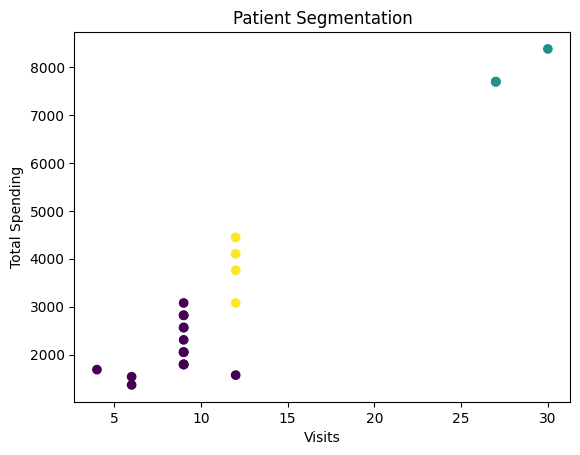

In [278]:
plt.scatter(patient_data['Visits'], patient_data['TotalAmount'], 
            c=patient_data['Cluster'])
plt.xlabel("Visits")
plt.ylabel("Total Spending")
plt.title("Patient Segmentation")
plt.show()

##### Patient segmentation reveals a clear high-value group contributing disproportionately to total revenue, alongside a large base of low utilization patients and a stable mid tier segment.

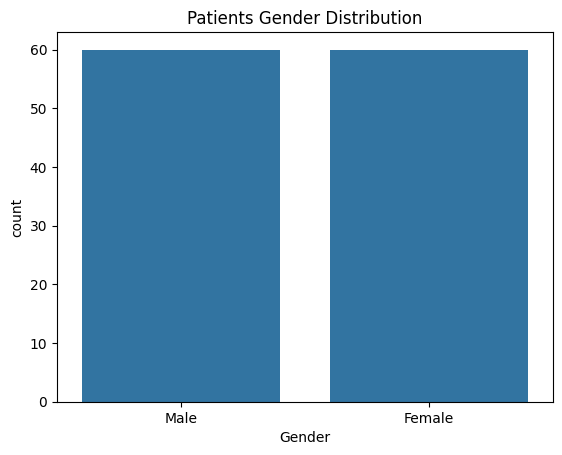

In [279]:
sns.countplot(data=df, x='Gender')
plt.title("Patients Gender Distribution")
plt.show()

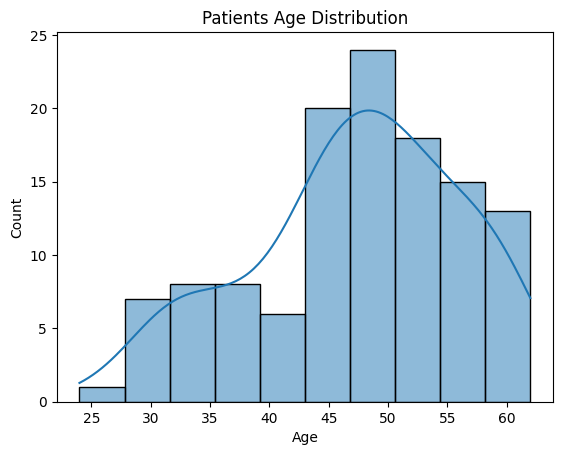

In [280]:
df['DateOfBirth'] = pd.to_datetime(df['DateOfBirth'])
df['Age'] = (pd.to_datetime('today') - df['DateOfBirth']).dt.days // 365

sns.histplot(df['Age'], bins=10, kde=True)
plt.title("Patients Age Distribution")
plt.show()

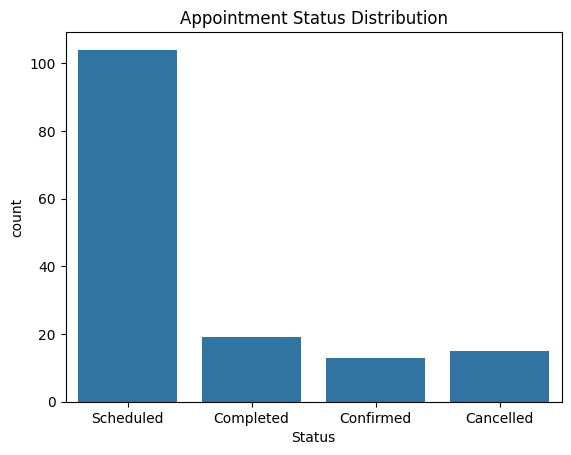

In [281]:
sns.countplot(data=df1, x='Status')
plt.title("Appointment Status Distribution")
plt.show()

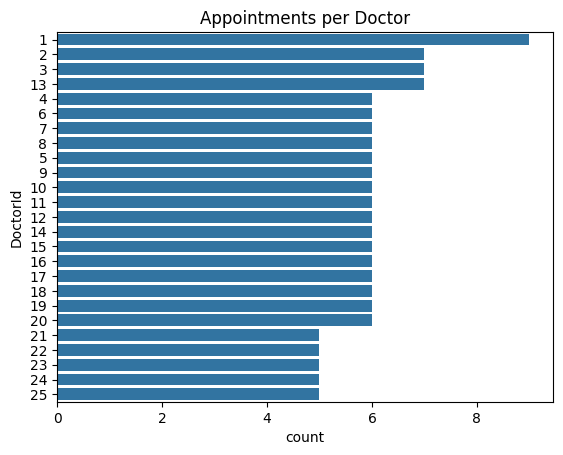

In [282]:
sns.countplot(data=df1, y='DoctorId', order=df1['DoctorId'].value_counts().index)
plt.title("Appointments per Doctor")
plt.show()

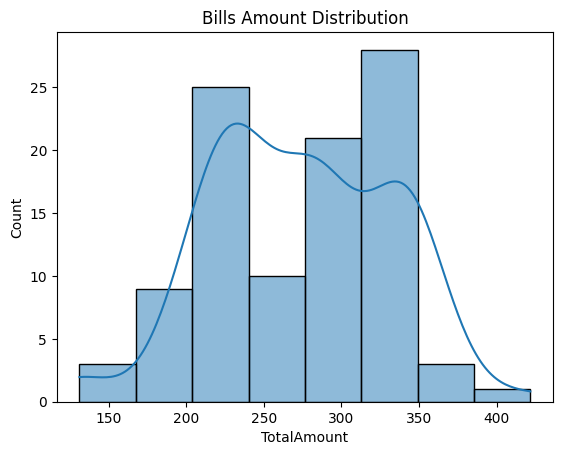

In [283]:
sns.histplot(df2['TotalAmount'], kde=True)
plt.title("Bills Amount Distribution")
plt.show()

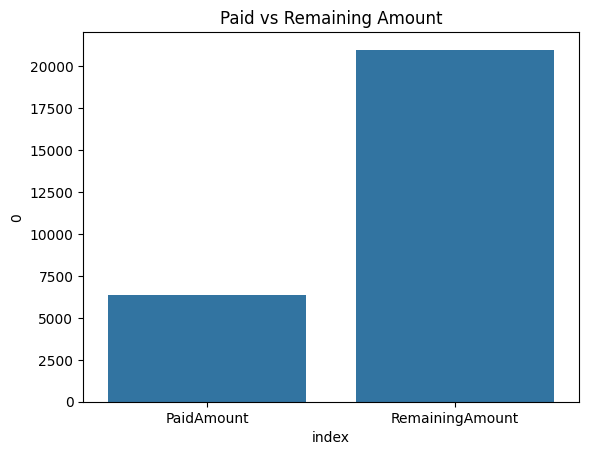

In [284]:
sns.barplot(data=df2[['PaidAmount','RemainingAmount']].sum().reset_index(),
            x='index', y=0)
plt.title("Paid vs Remaining Amount")
plt.show()

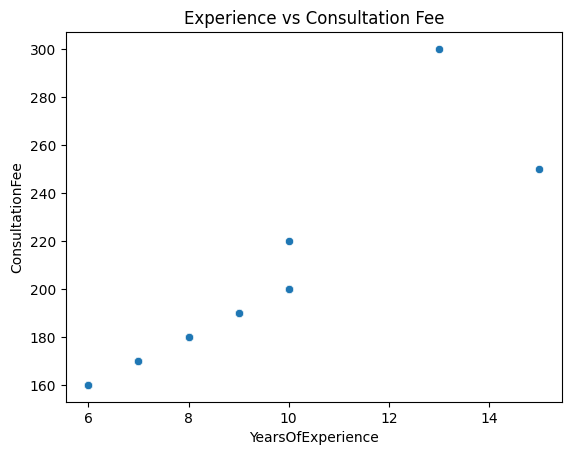

In [285]:
sns.scatterplot(data=df3, x='YearsOfExperience', y='ConsultationFee')
plt.title("Experience vs Consultation Fee")
plt.show()

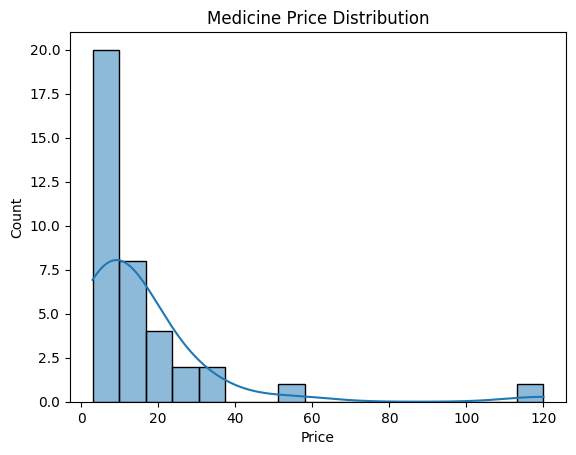

In [286]:
sns.histplot(df4['Price'], kde=True)
plt.title("Medicine Price Distribution")
plt.show()

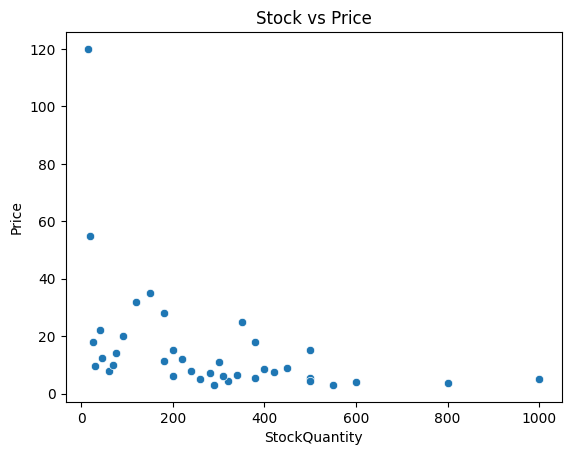

In [287]:
sns.scatterplot(data=df4, x='StockQuantity', y='Price')
plt.title("Stock vs Price")
plt.show()

### During analysis, several data quality issues were identified:

##### 1. Missing and incomplete fields
###### Medical details (Diagnosis, Treatment, Notes) are almost empty in appointments.
###### Payment tracking fields (PaymentMethod, PaymentDate) are missing in most records.
###### Some medicine clinical fields (Contraindications, SideEffects, DosageInstructions) are partially missing.
###### UpdatedAt fields across multiple tables are mostly empty and unused.

#### 2. Lack of relational consistency
##### No direct linkage between prescriptions and medicines.
##### Treatment data is not structured, limiting medical analysis.

#### 3. Data fragmentation
##### Some important business flows (like prescription → medicine usage) are not captured in the dataset.

## Recommendations for System Improvement
#### 1. Improve Data Completeness
Enforce mandatory fields for:
Diagnosis
Treatment
Payment Method
Payment Date
Prevent saving records with critical missing information.

#### 2. Introduce Prescription Tracking System
Add a new table:
Prescriptions
Link:
PatientId
DoctorId
MedicineId
Dosage
Duration

This will enable:

Real medicine usage analysis
Patient treatment tracking
Drug safety monitoring

#### 3. Enhance Financial Tracking
Ensure real-time recording of:
Payments
Partial payments
Insurance coverage contributions

This will improve:

Collection rate accuracy
Cash flow monitoring
Financial forecasting

## Patient Centered Improvement Recommendations

To better serve patients, the system should focus on:

1- Reducing waiting time by optimizing doctor schedules.
2- Ensuring safe prescription by linking medical history with drug contraindications.
3- Improving billing transparency and payment tracking.
4- Using patient clustering to provide personalized healthcare plans:
5- VIP care for high value patients
6- Preventive care for low utilization patients
7- Implementing reminder systems for follow up appointments and payments.